In [15]:
from datasets import load_dataset, get_dataset_config_names
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from transformers import AutoTokenizer

In [16]:
mcqa_dataset_name = "andresnowak/MNLP_MCQA_dataset"

In [17]:
mcqa_dataset_configs = get_dataset_config_names(mcqa_dataset_name)

README.md:   0%|          | 0.00/7.13k [00:00<?, ?B/s]

In [18]:
mcqa_dataset_configs

['ScienceQA',
 'ai2_arc_challenge',
 'ai2_arc_easy',
 'all',
 'math_qa',
 'medmcqa',
 'mmlu',
 'mmlu-auxiliary-train-auto-labelled',
 'openbookqa',
 'sciq']

In [19]:
mcqa_datasets = [load_dataset(mcqa_dataset_name, config) for config in mcqa_dataset_configs]

Generating train split:   0%|          | 0/3018 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1070 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1041 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1119 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/299 [00:00<?, ? examples/s]

...

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/11679 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

**Science QA in majority has just around two choices for each question, so it doesn't have a bias there is no problem**

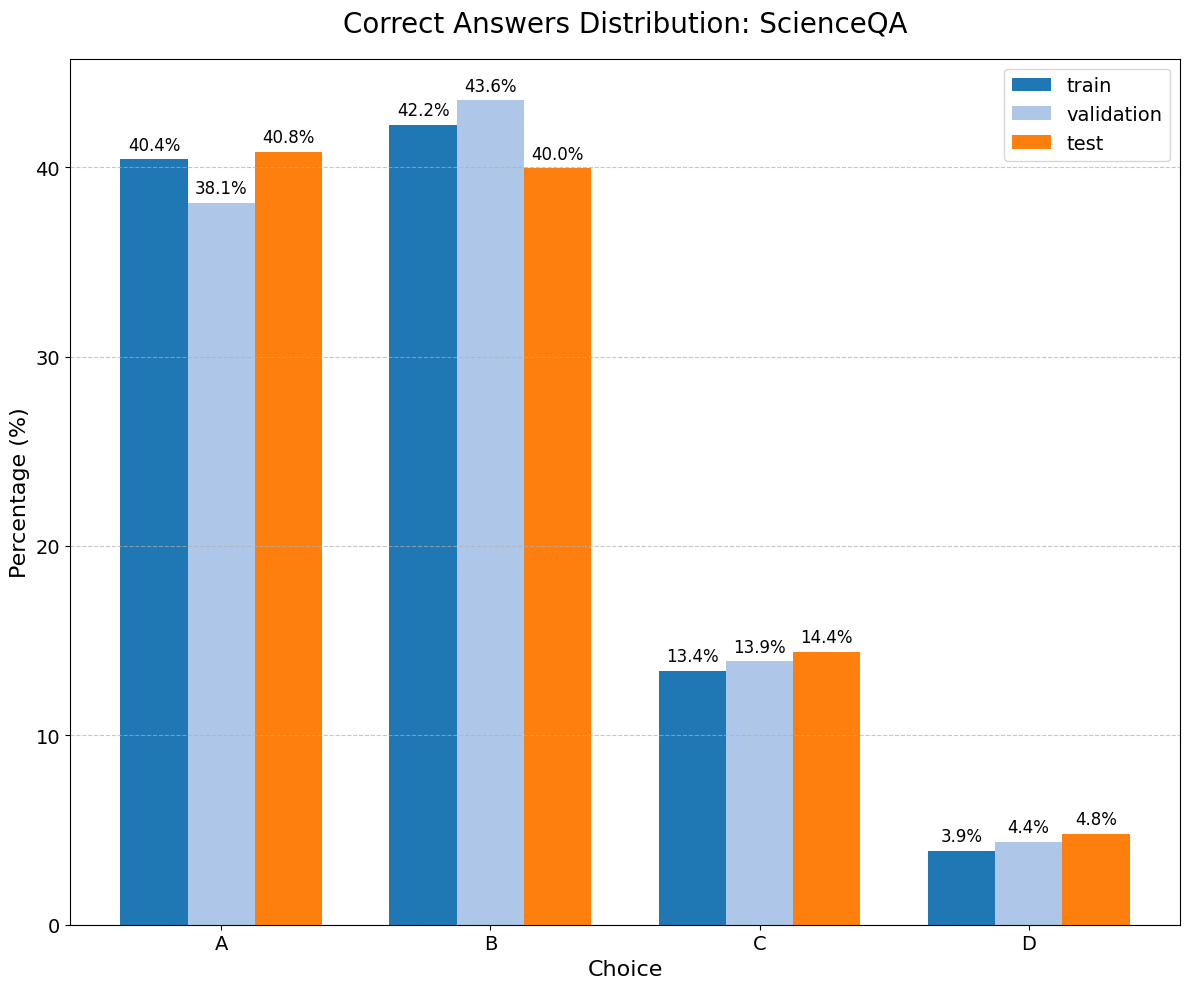

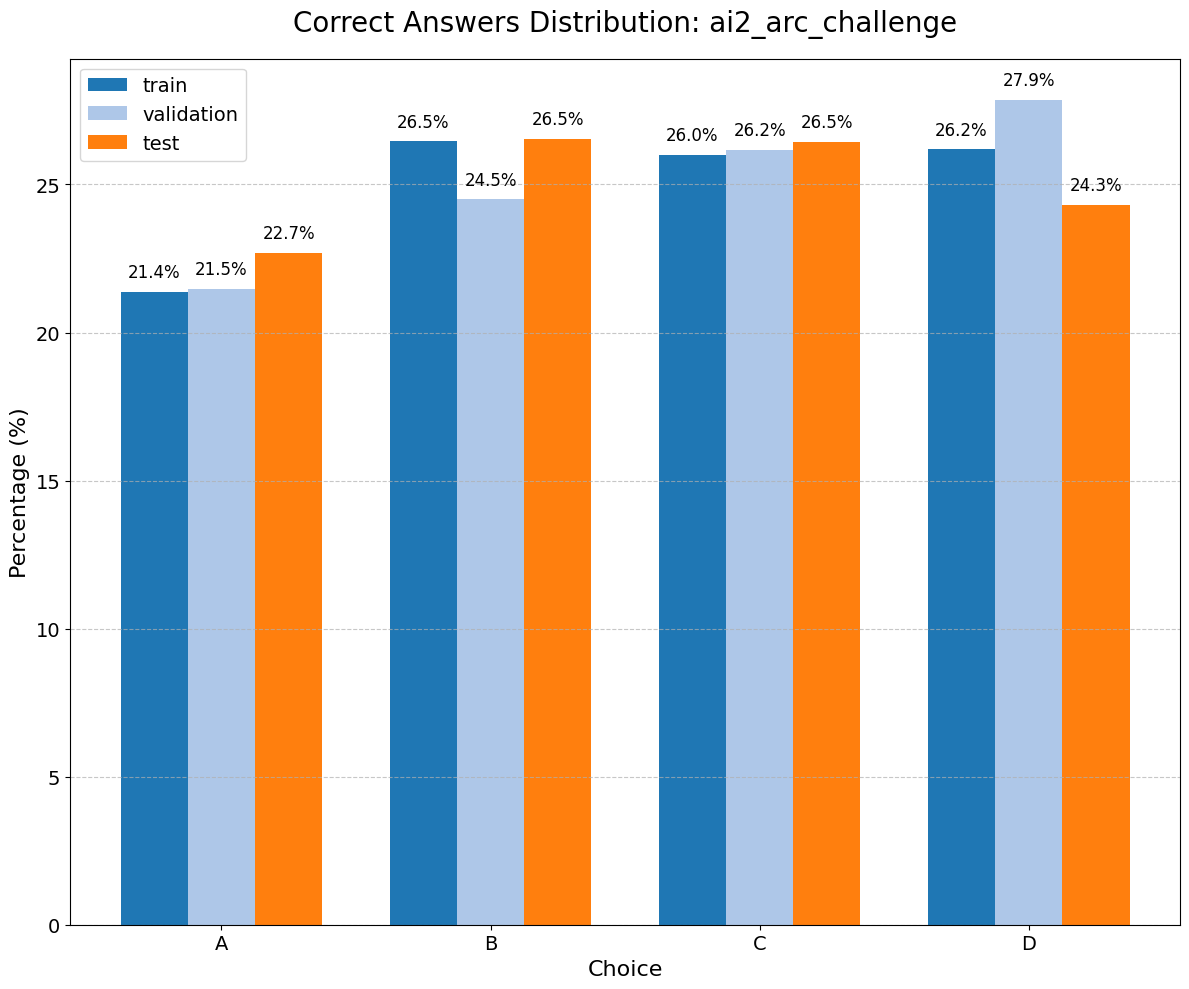

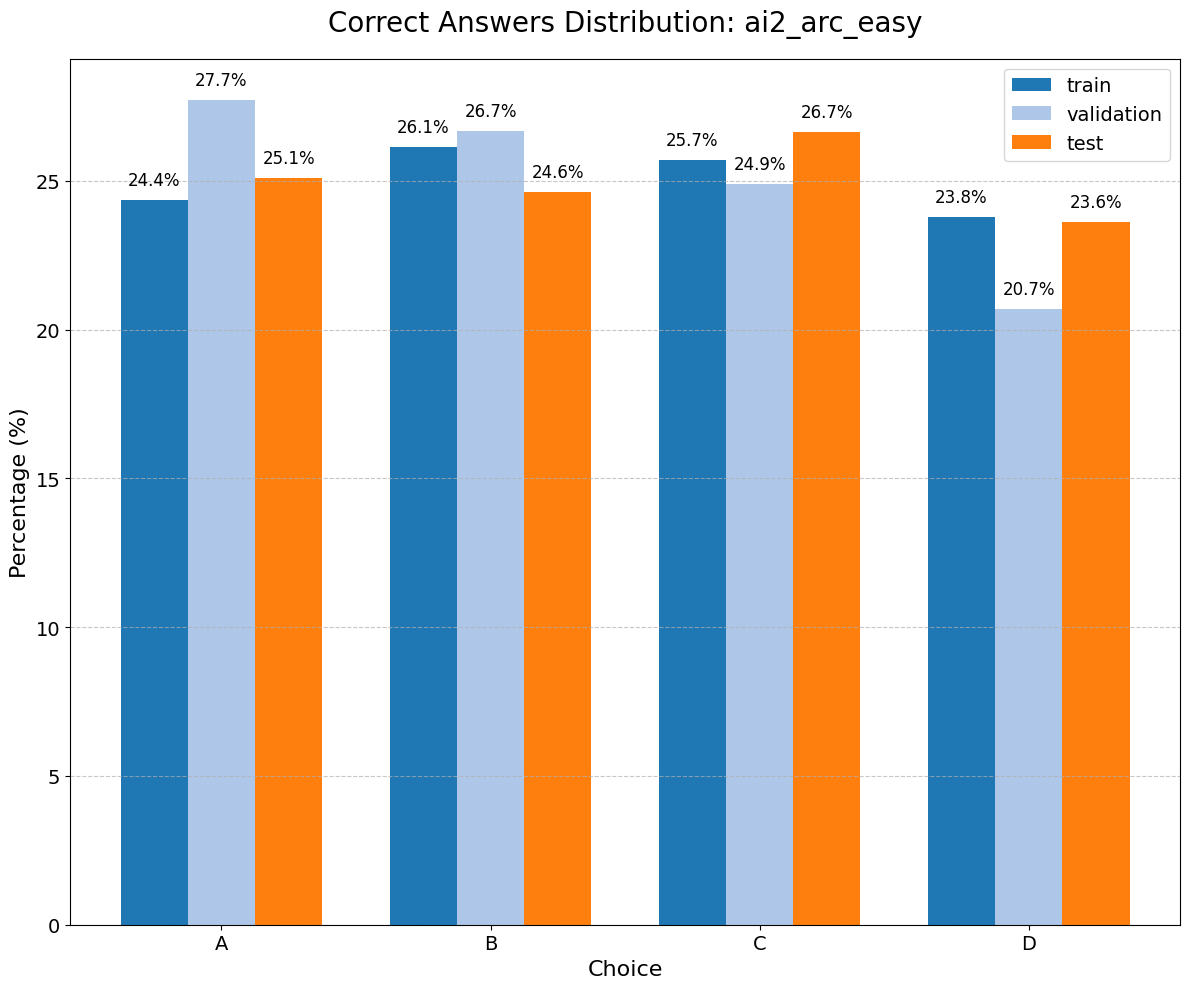

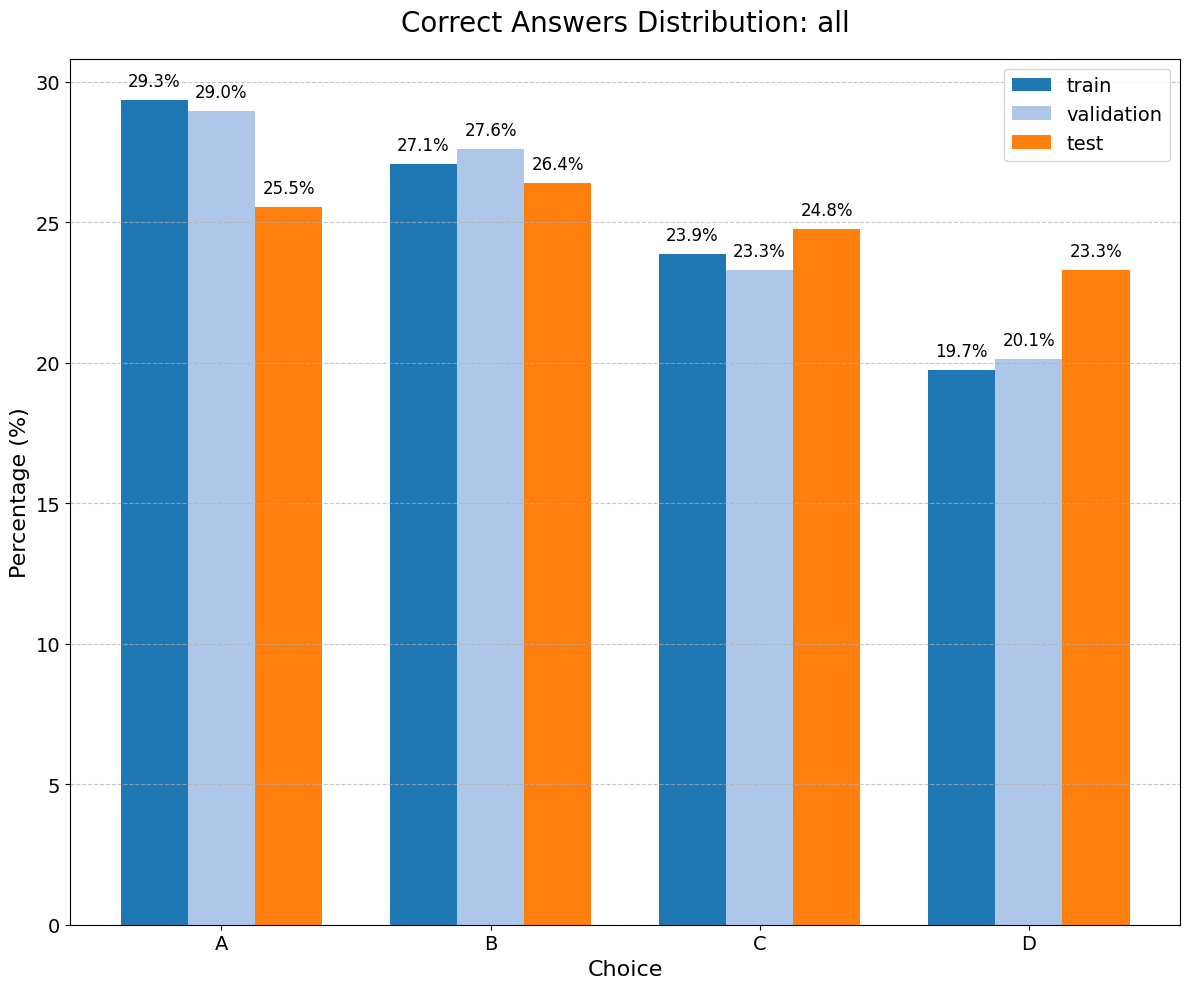

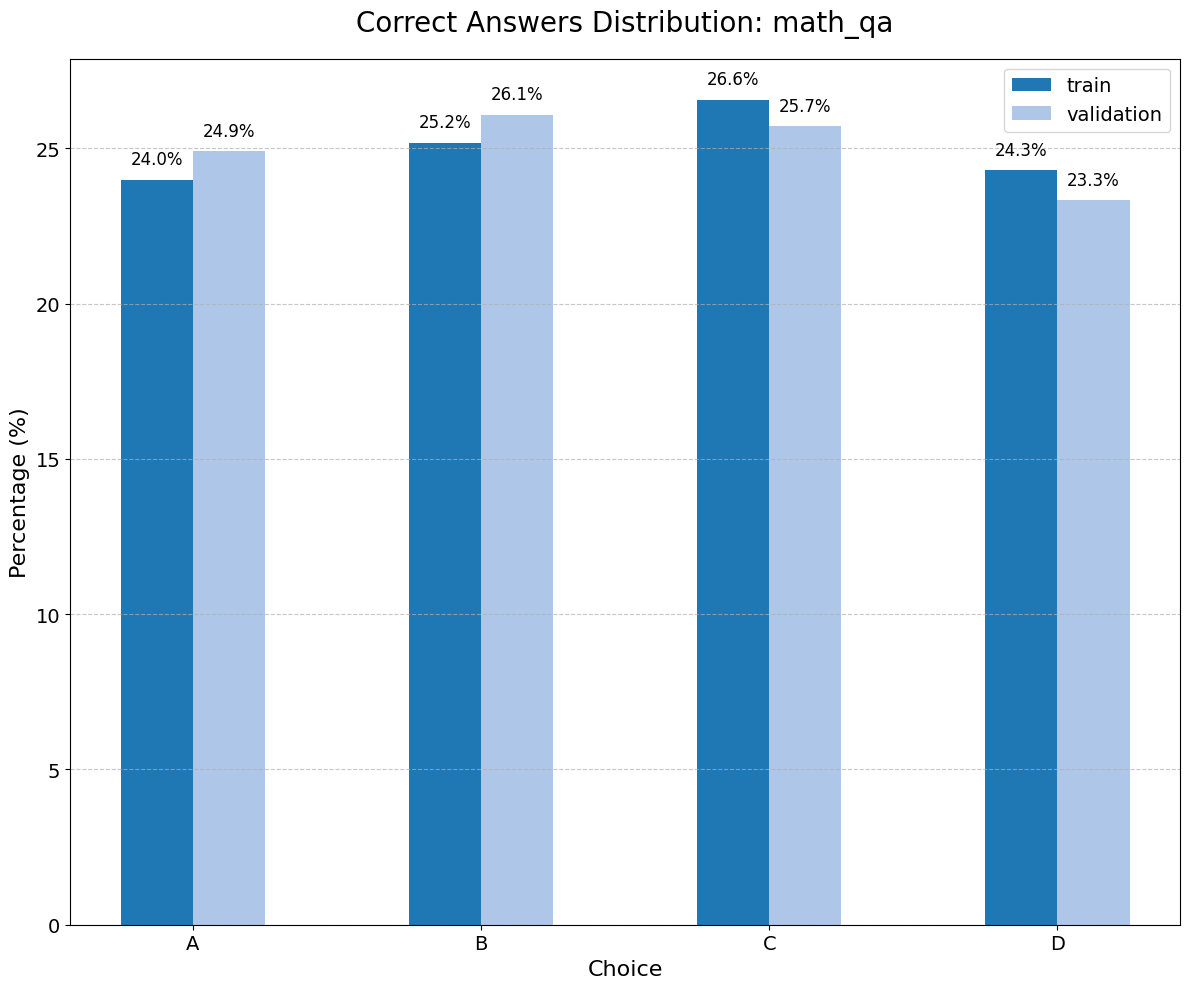

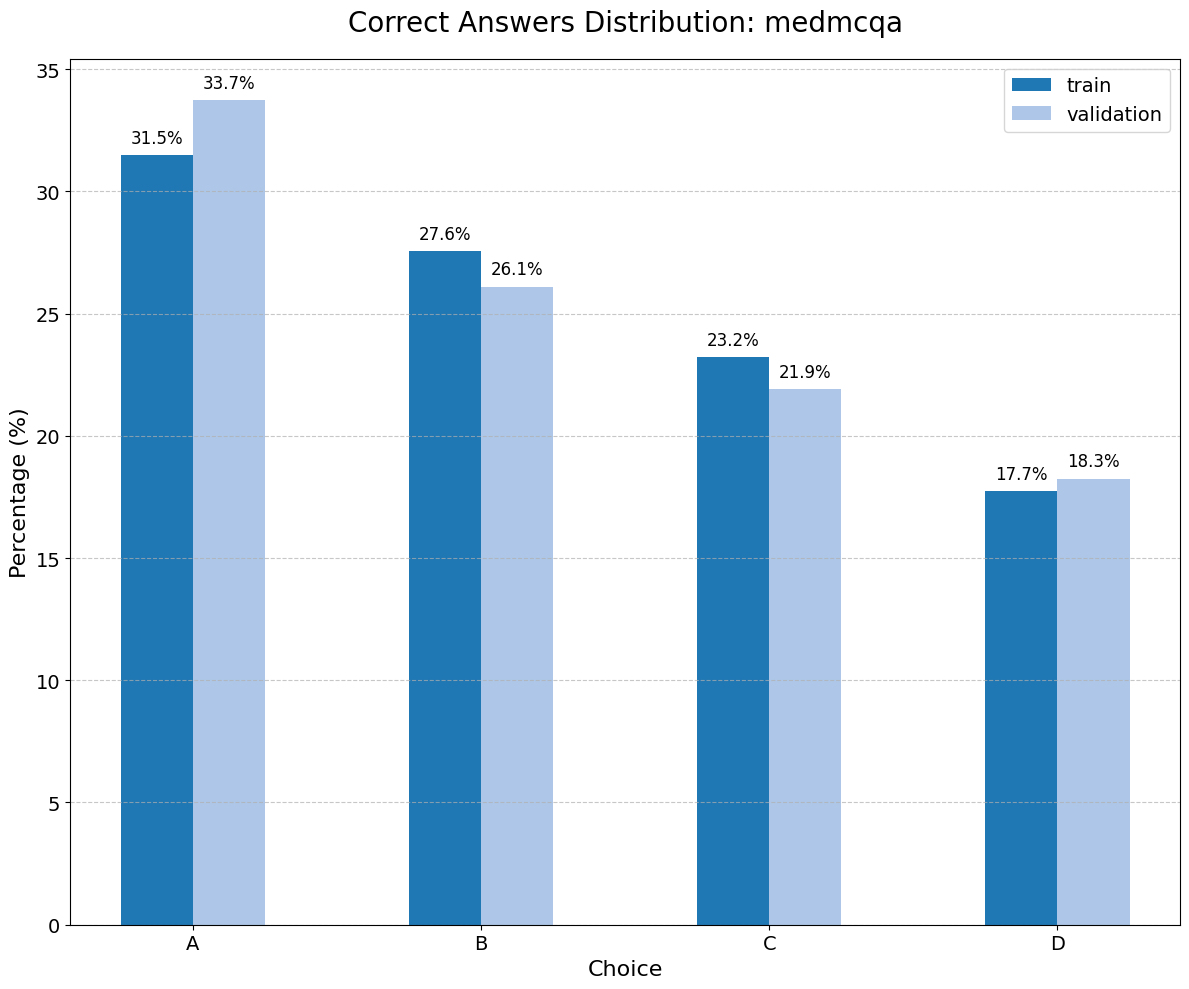

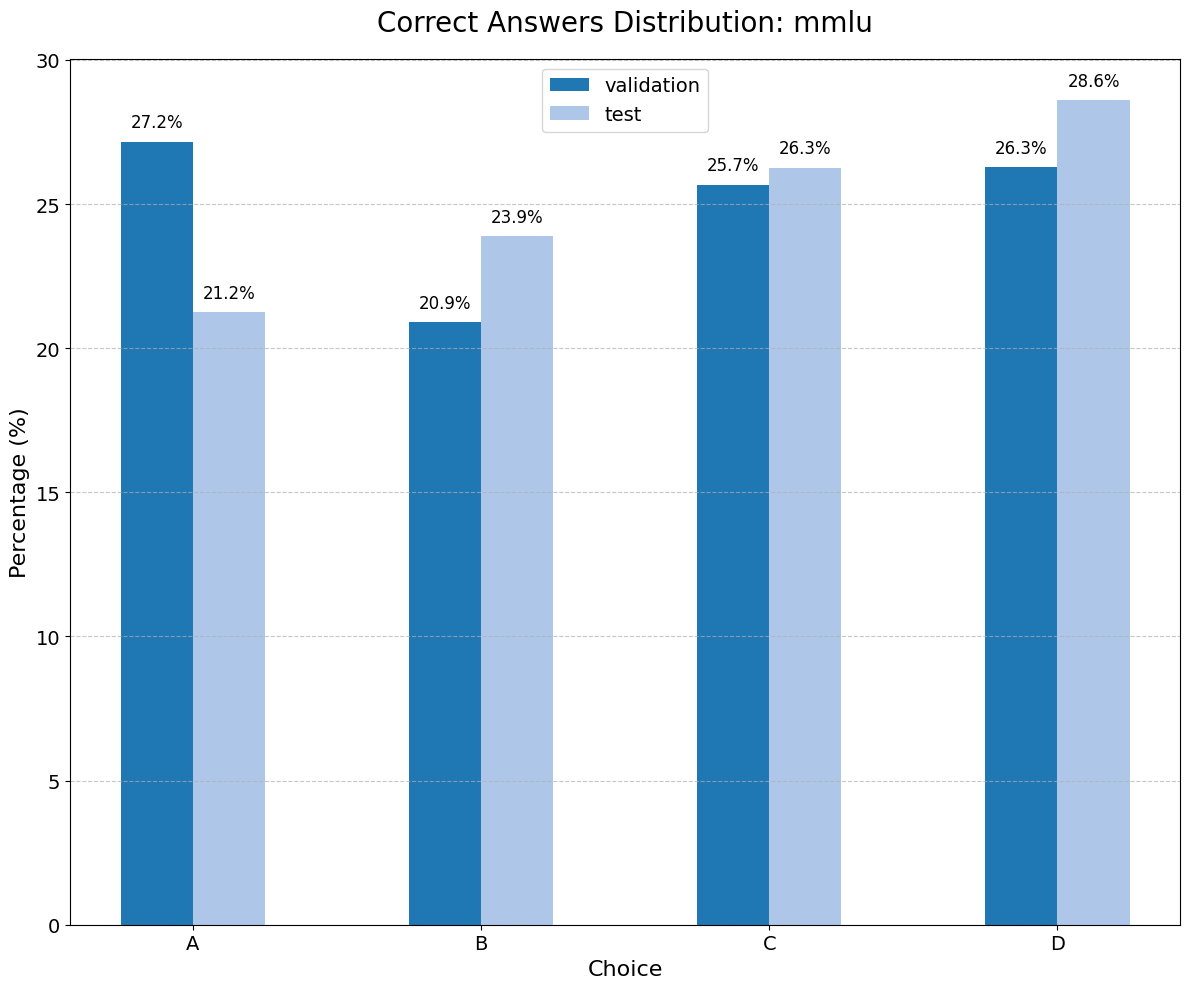

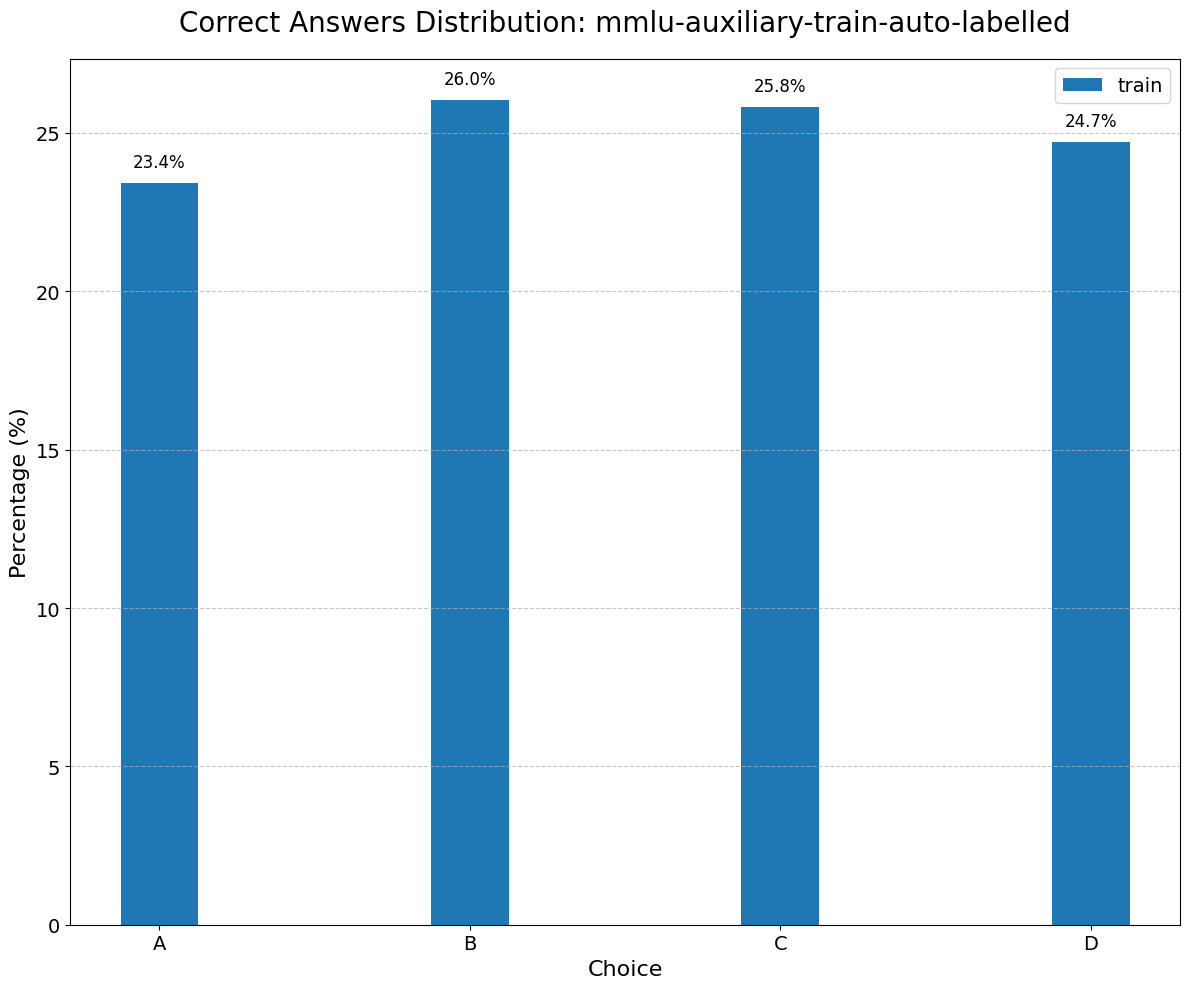

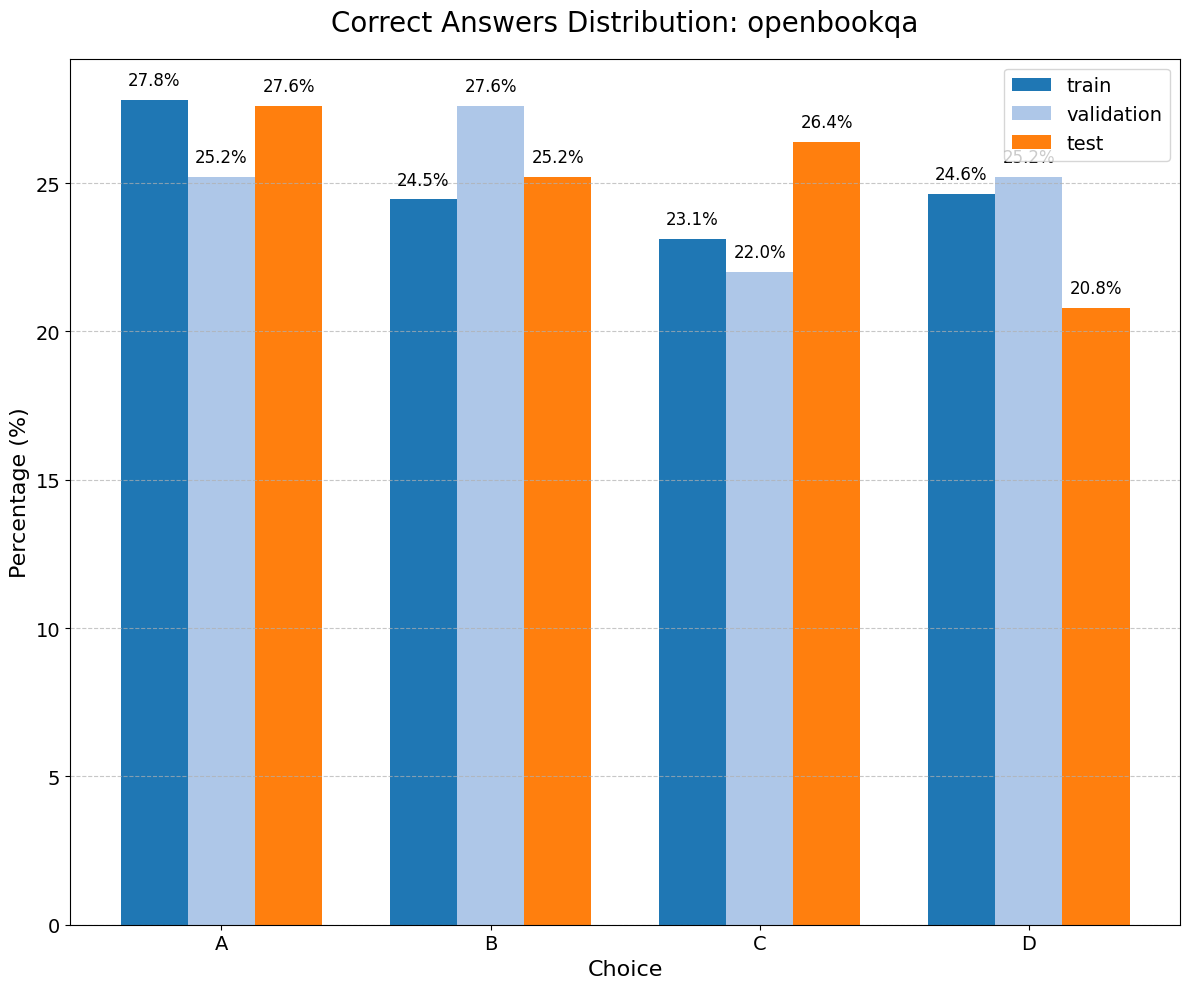

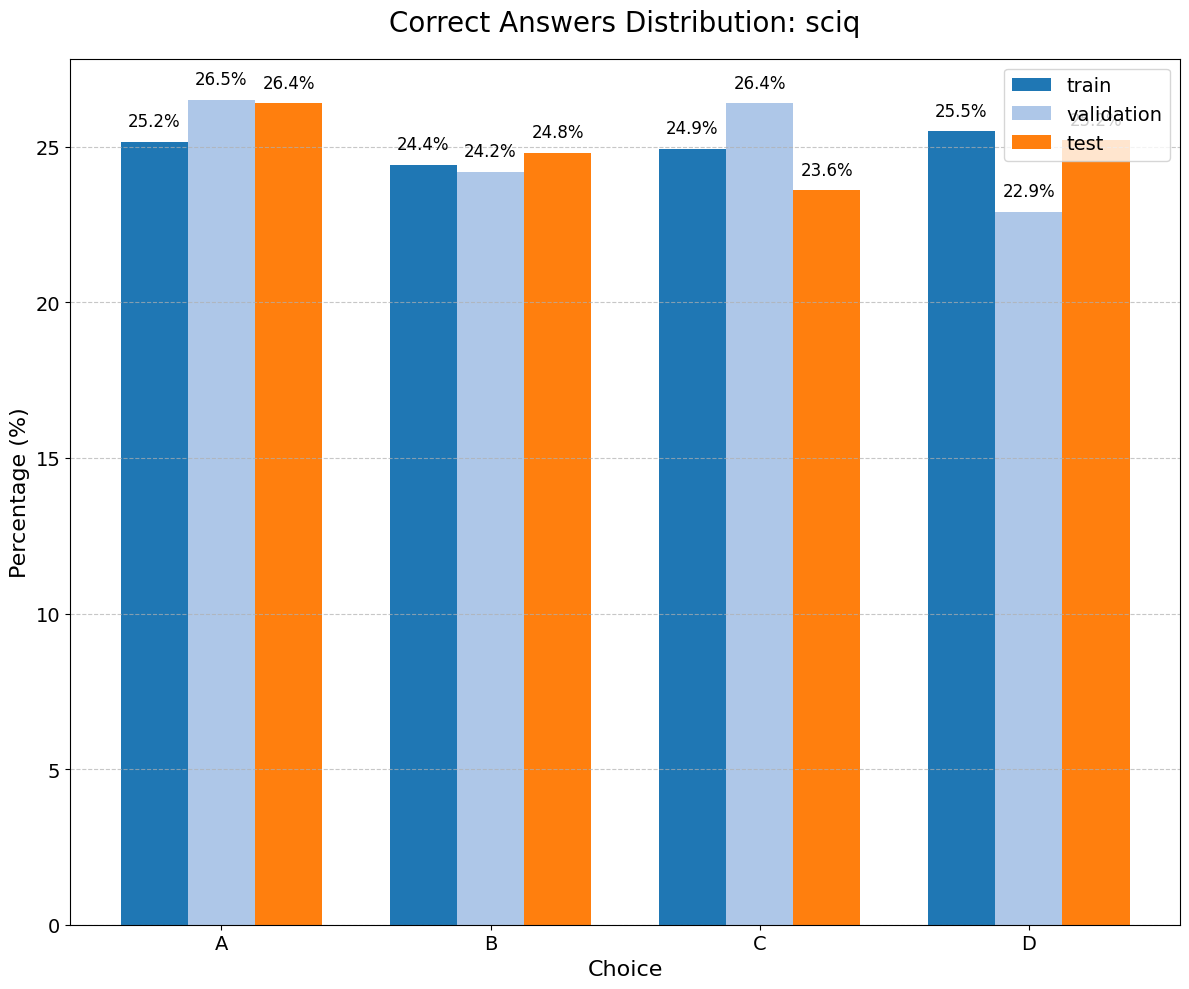

In [20]:
for name, subset in zip(mcqa_dataset_configs, mcqa_datasets):
    # --- Initialize figure (20x10) ---
    fig, ax = plt.subplots(figsize=(12, 10))

    # Collect data for all splits
    splits = list(subset.keys())
    choices = ["A", "B", "C", "D"]  # Adjust if different

    # Create a DataFrame to store percentages
    df = pd.DataFrame(index=choices)

    for split in splits:
        answers = subset[split]["answer"]
        counts = pd.Series(answers).value_counts().reindex(choices, fill_value=0)
        df[split] = (counts / counts.sum()) * 100  # Convert to percentages

    # --- Plot grouped bars ---
    bar_width = 0.25
    index = np.arange(len(choices))

    for i, split in enumerate(splits):
        ax.bar(
            index + i * bar_width,
            df[split],
            width=bar_width,
            label=split,
            color=plt.cm.tab20(i),  # Distinct colors per split
        )

    # --- Customize plot ---
    ax.set_title(f"Correct Answers Distribution: {name}", fontsize=20, pad=20)
    ax.set_xlabel("Choice", fontsize=16)
    ax.set_ylabel("Percentage (%)", fontsize=16)
    ax.set_xticks(index + bar_width * (len(splits) - 1) / 2)
    ax.set_xticklabels(choices, fontsize=14)
    ax.tick_params(axis="y", labelsize=14)
    ax.legend(fontsize=14)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    # Add value labels
    for i, split in enumerate(splits):
        for j, choice in enumerate(choices):
            height = df.loc[choice, split]
            ax.text(
                j + i * bar_width,
                height + 0.5,
                f"{height:.1f}%",
                ha="center",
                fontsize=12,
            )

    plt.tight_layout()  # Prevent label overlap
    plt.show()


In [7]:
instruction_finetuning_dataset_name = "andresnowak/Instruction-finetuning-mixture-mnlp"

In [8]:
instruction_finetuning_dataset_configs = get_dataset_config_names(instruction_finetuning_dataset_name)

In [9]:
instruction_finetuning_datasets = [
    load_dataset(instruction_finetuning_dataset_name, config) for config in instruction_finetuning_dataset_configs
]


In [10]:
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-0.6B-Base")

Sizes of each datasets

- Aya subset has very long long messages but average is 362 it seems

Processing all: 100%|██████████| 1/1 [05:05<00:00, 305.13s/it]


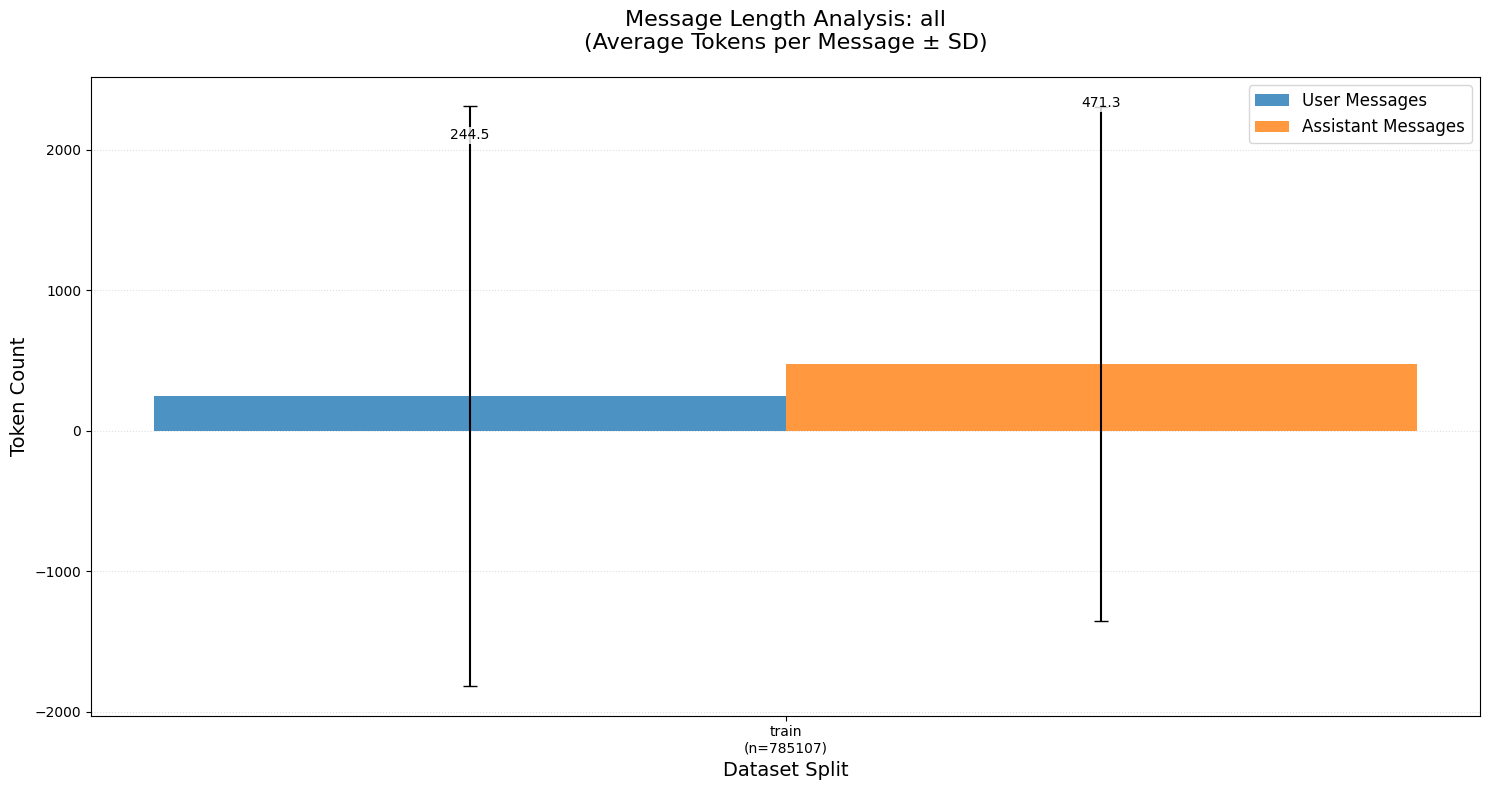

Processing aya: 100%|██████████| 1/1 [00:25<00:00, 25.86s/it]


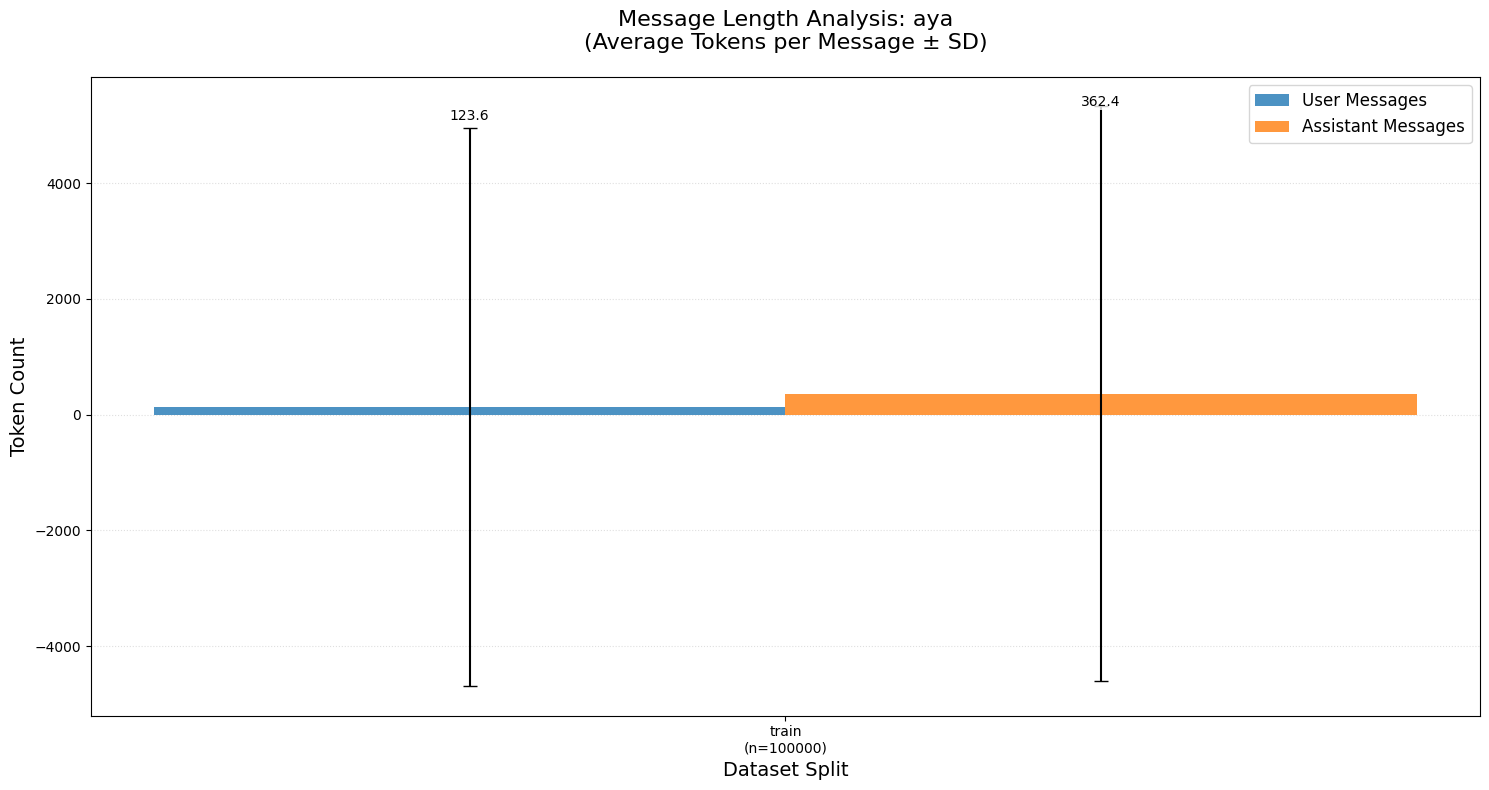

Processing codeAlpaca: 100%|██████████| 1/1 [00:32<00:00, 32.73s/it]


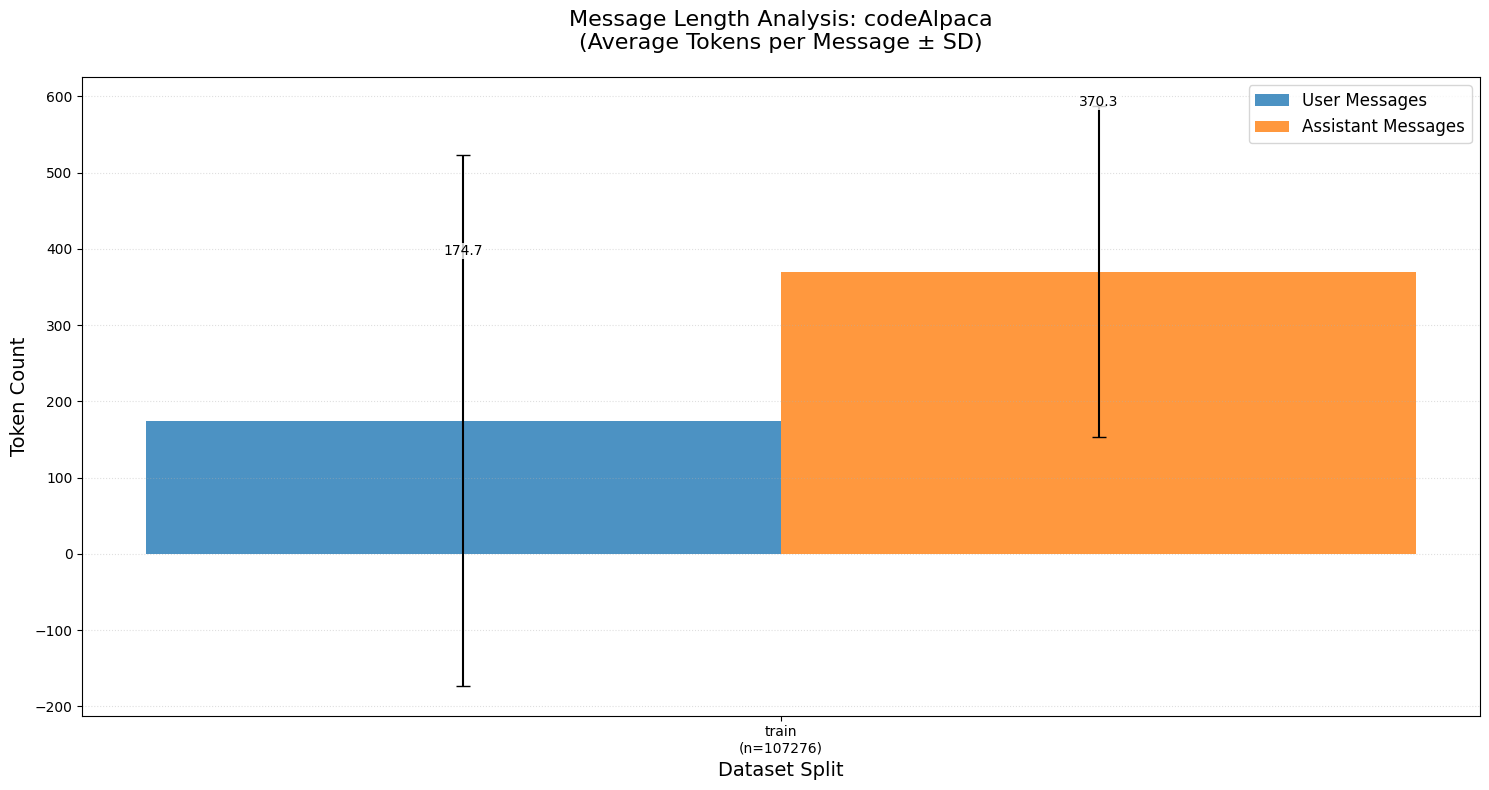

Processing codeV2: 100%|██████████| 1/1 [00:07<00:00,  7.46s/it]


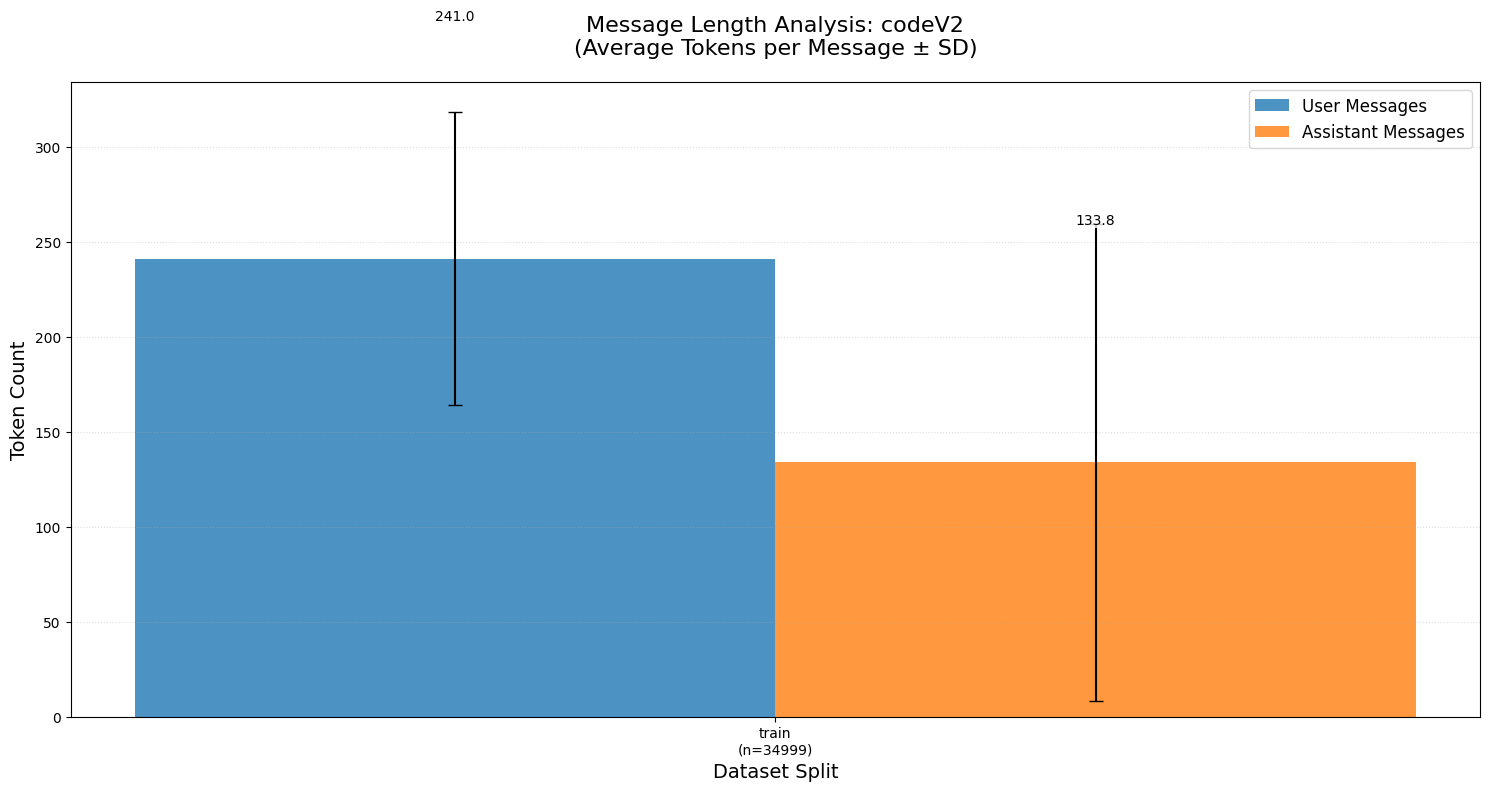

Processing flanV2: 100%|██████████| 1/1 [00:17<00:00, 17.18s/it]


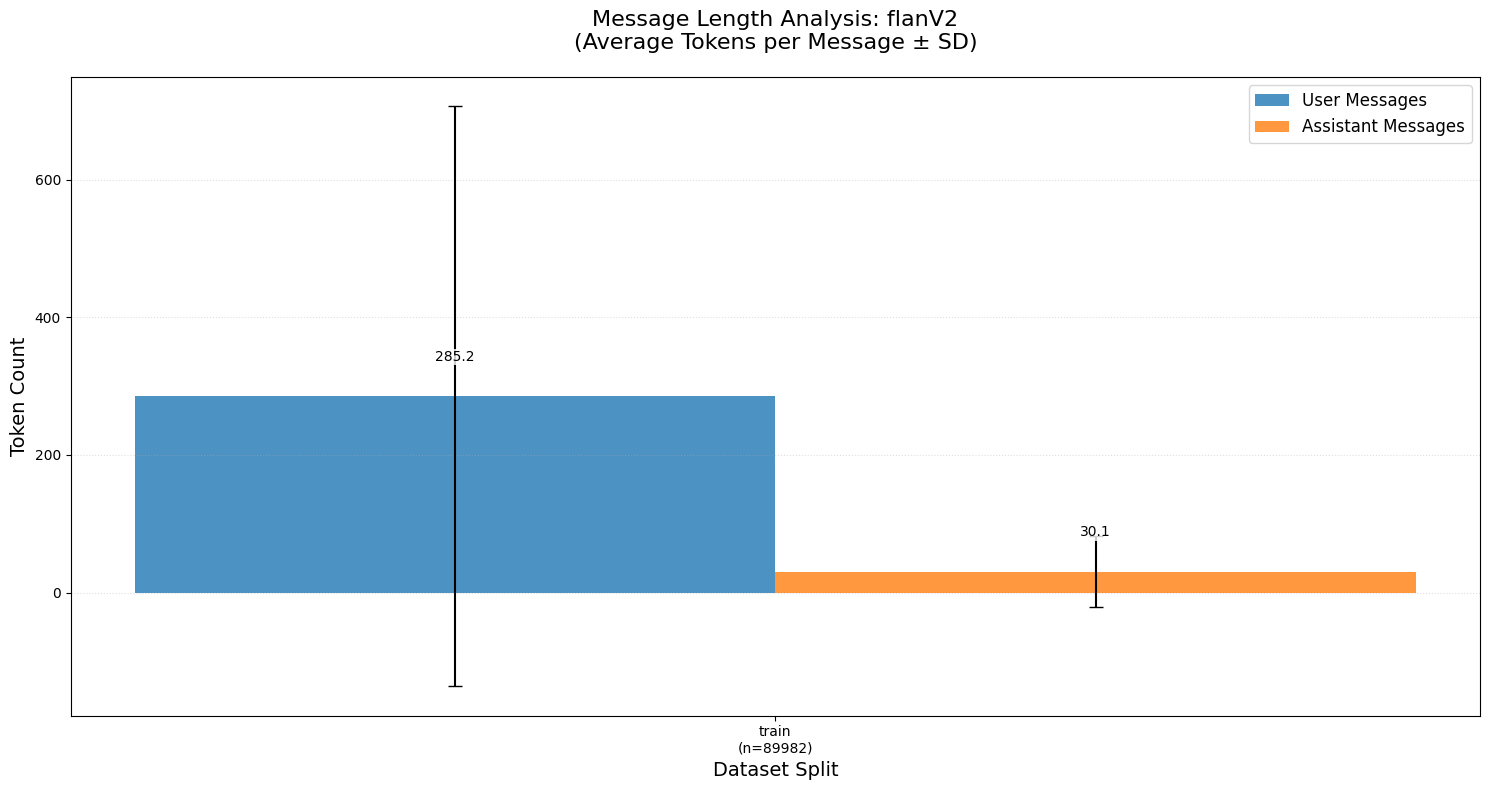

Processing hardCoded: 100%|██████████| 1/1 [00:00<00:00, 276.94it/s]


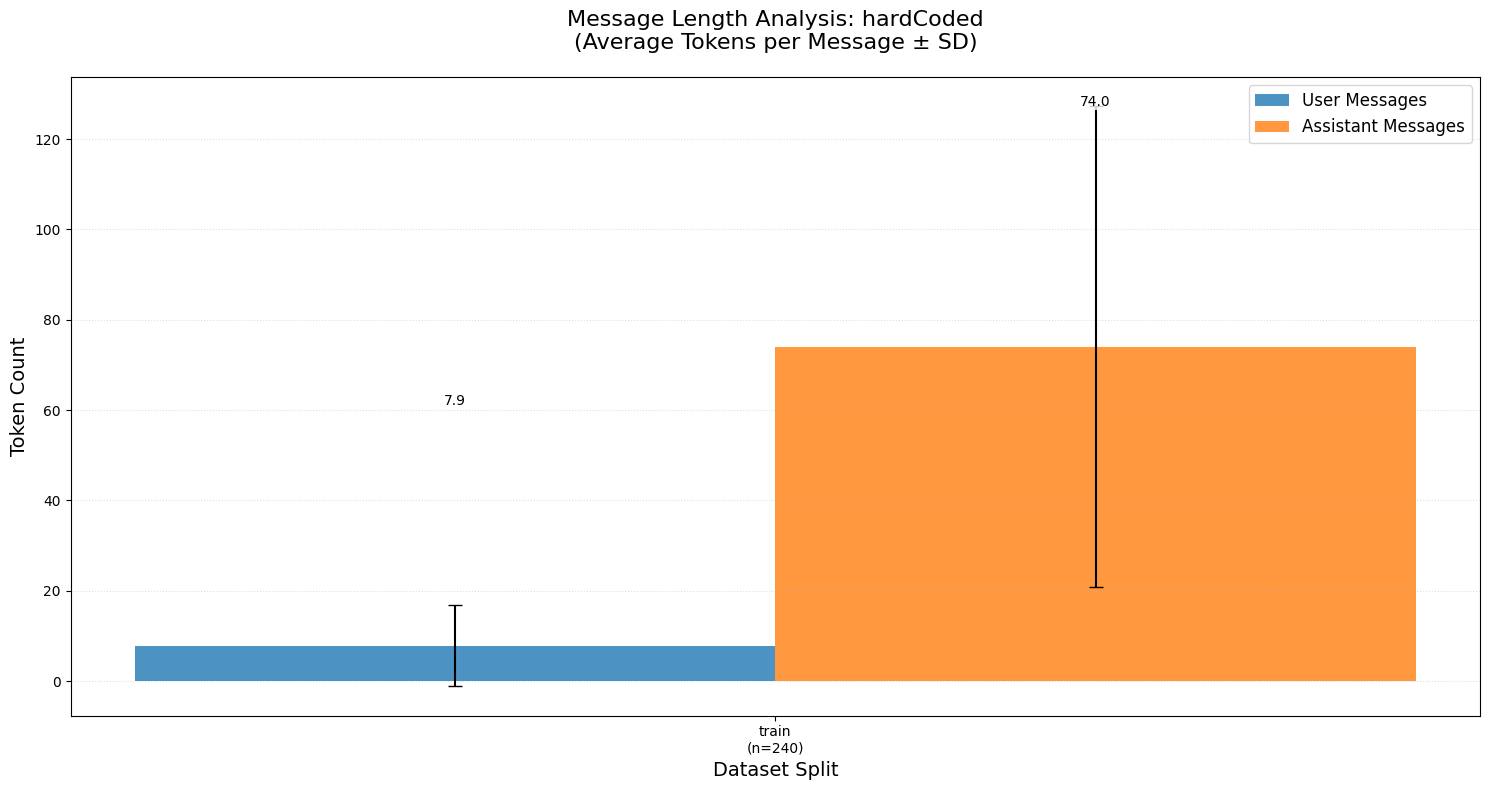

Processing ifData: 100%|██████████| 1/1 [00:07<00:00,  7.28s/it]


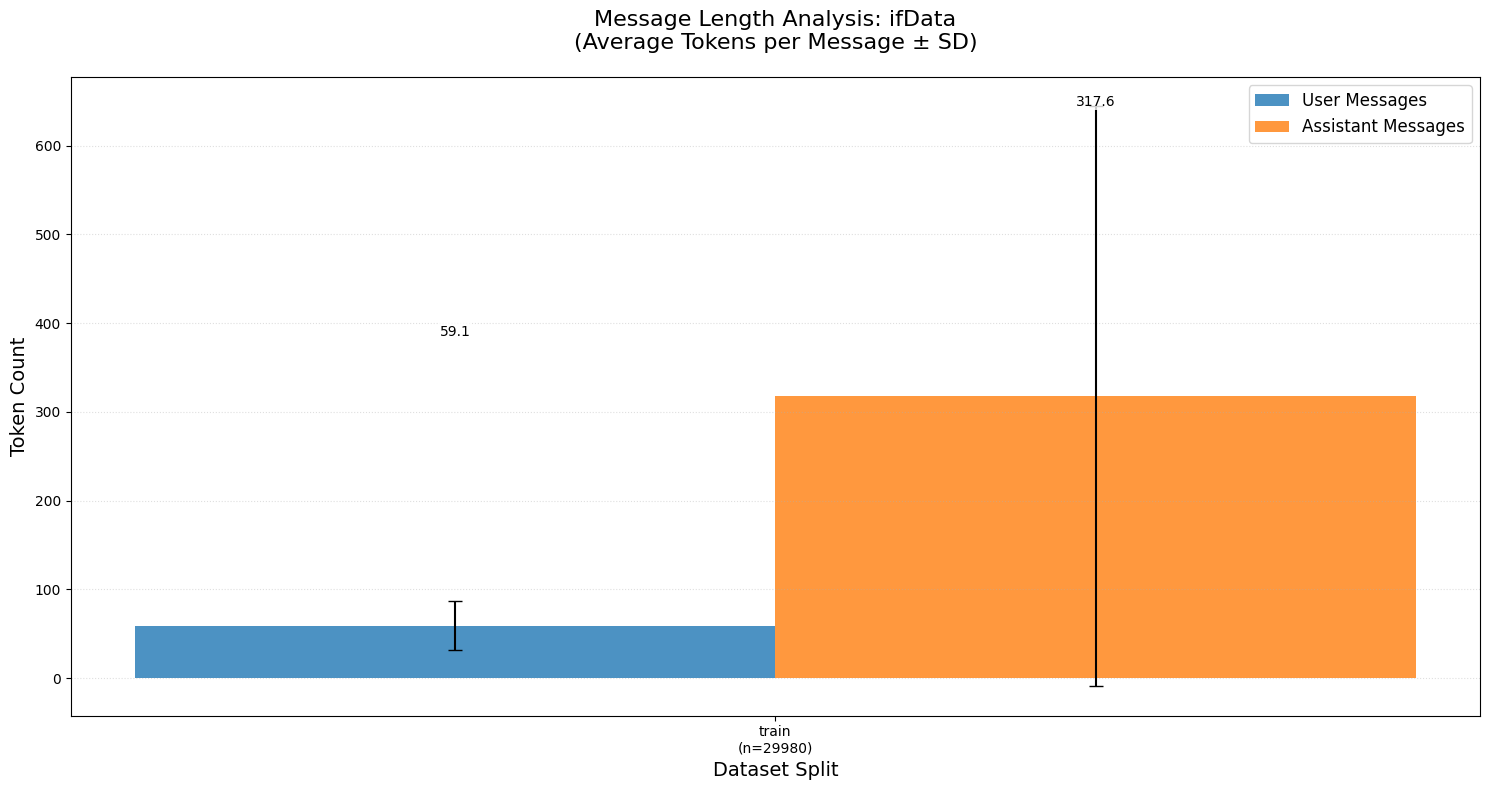

Processing mathAlgebra: 100%|██████████| 1/1 [00:10<00:00, 10.60s/it]


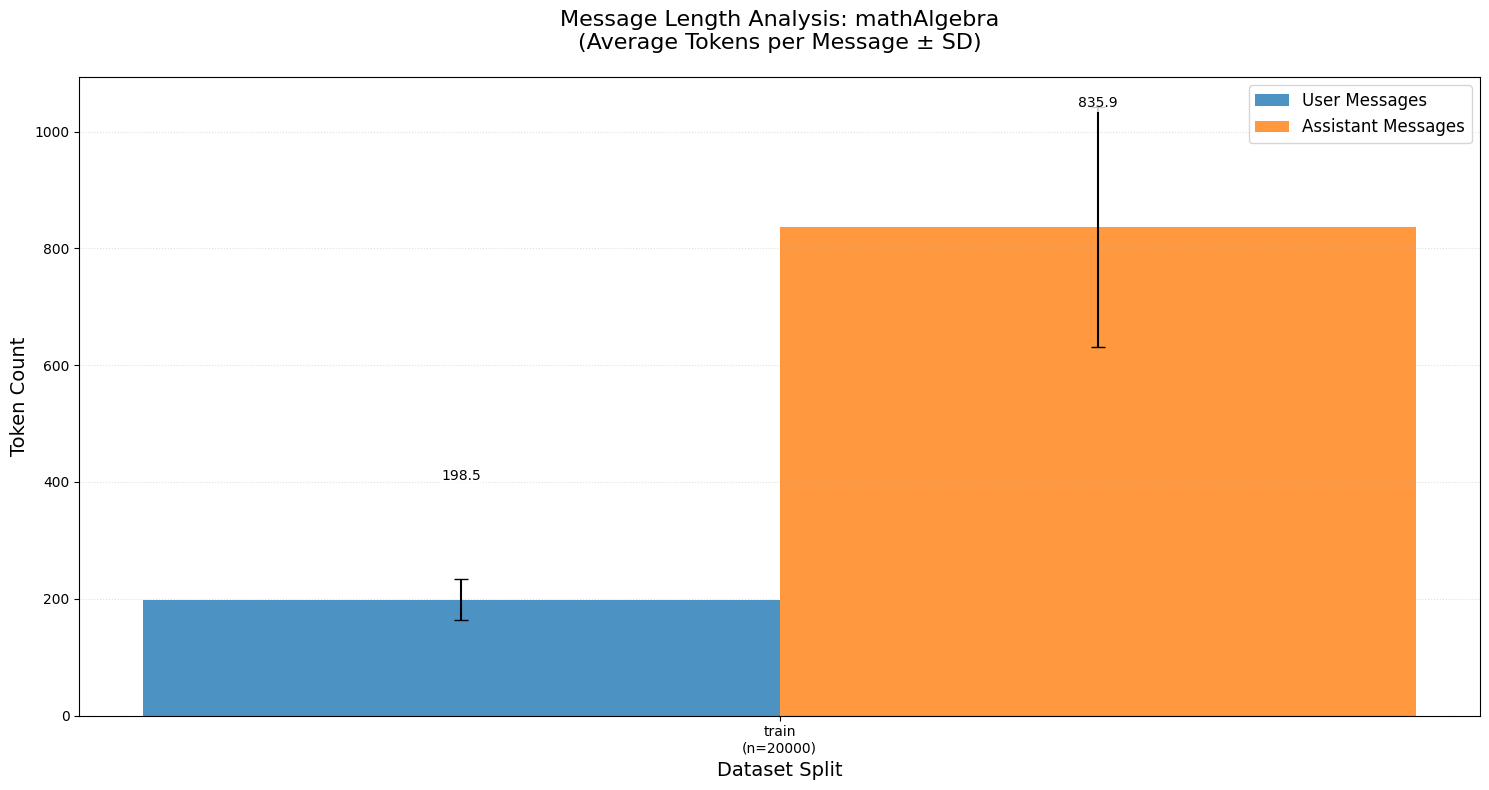

Processing mathGrade: 100%|██████████| 1/1 [00:12<00:00, 12.35s/it]


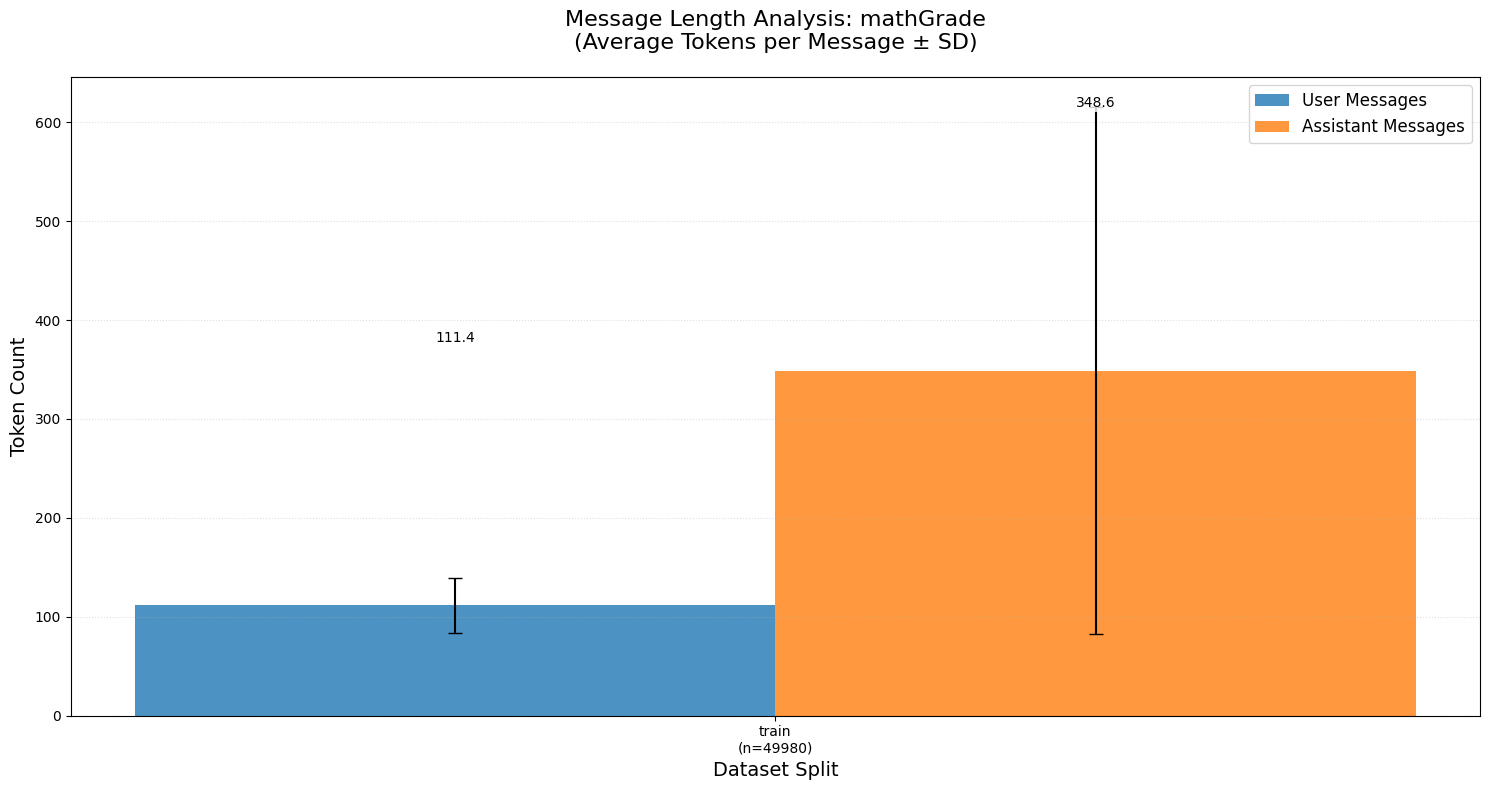

Processing mathV5: 100%|██████████| 1/1 [01:55<00:00, 115.83s/it]


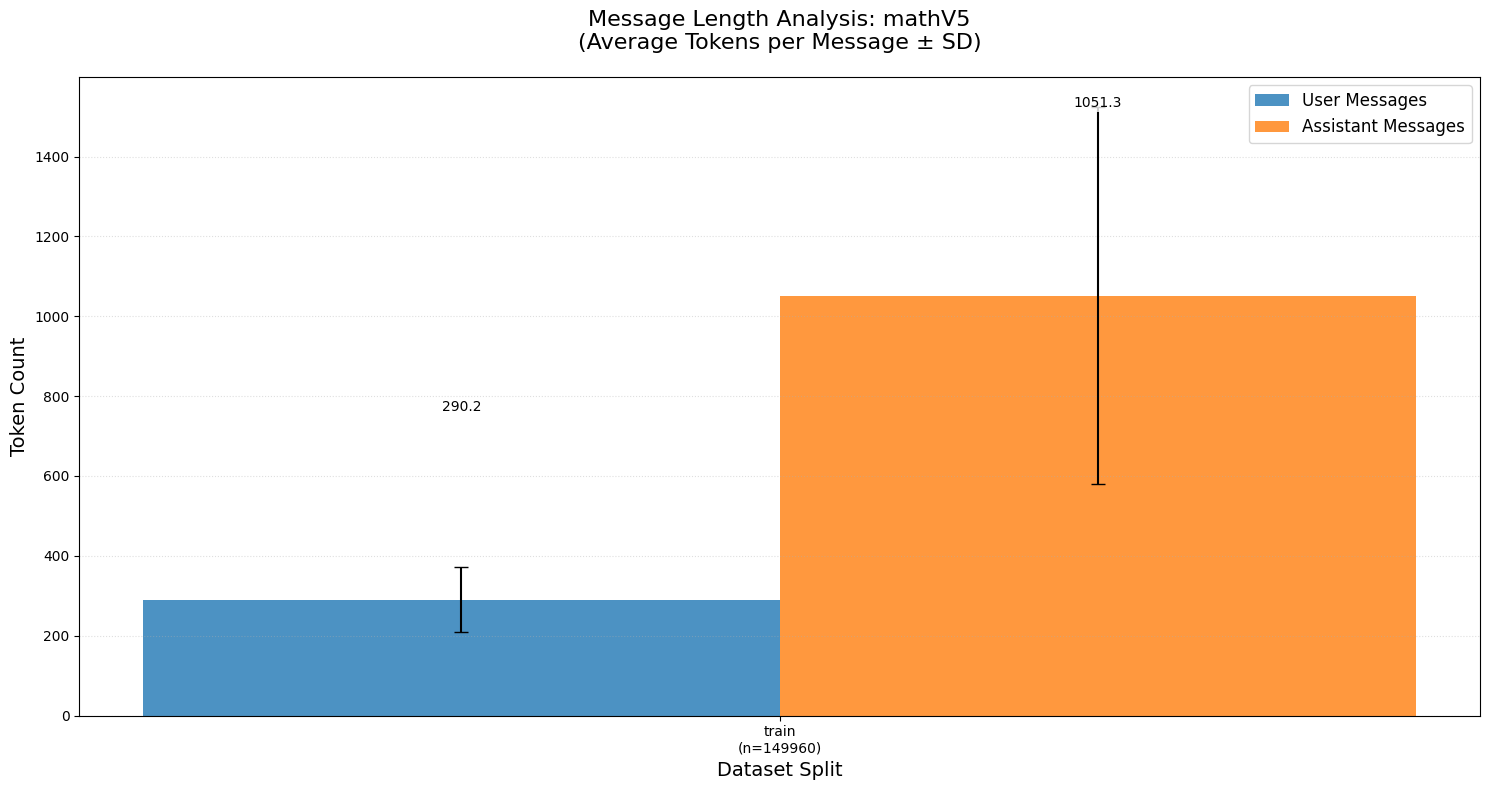

Processing noRobots: 100%|██████████| 1/1 [00:01<00:00,  1.59s/it]


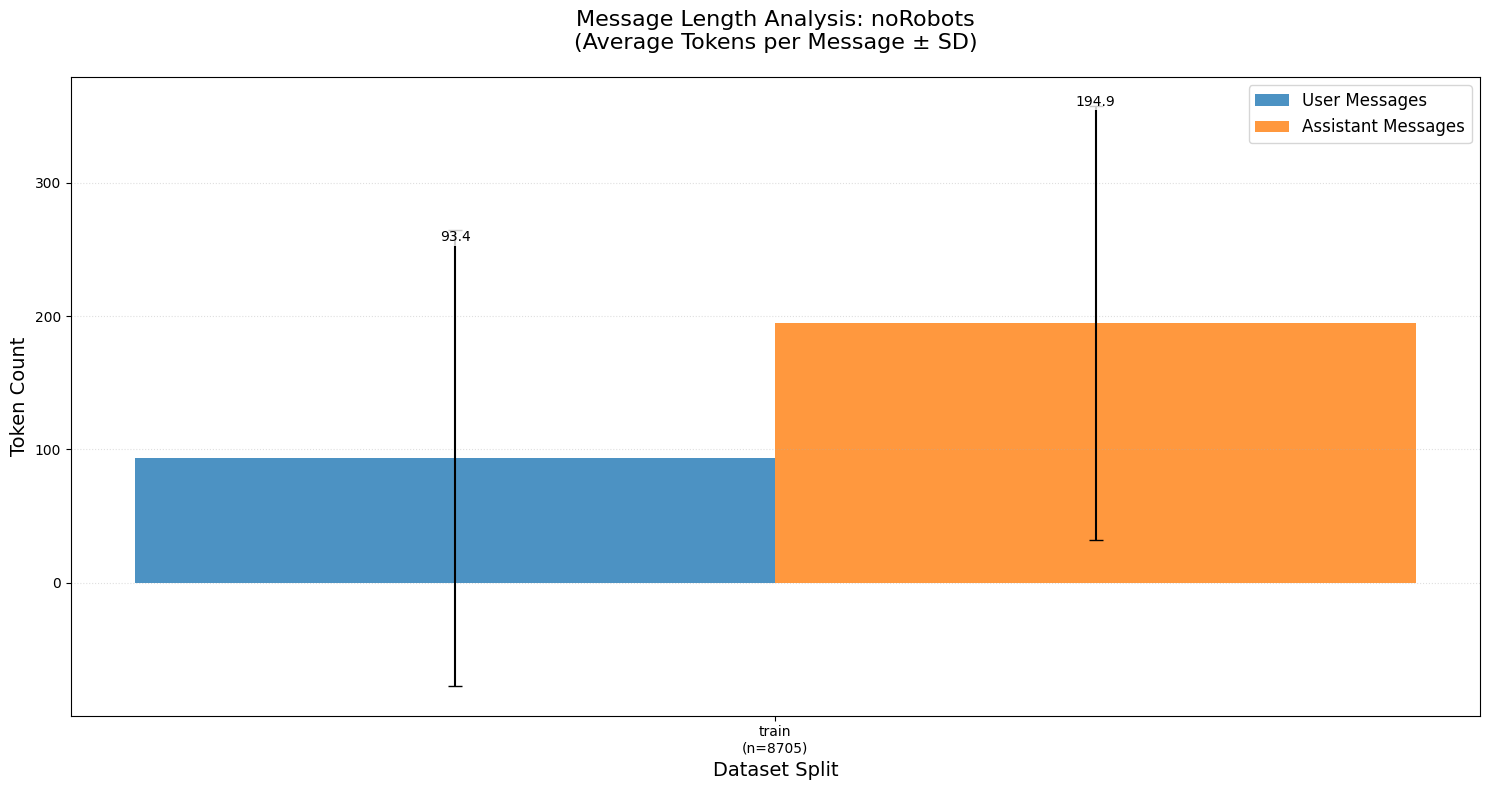

Processing oasst1: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s]


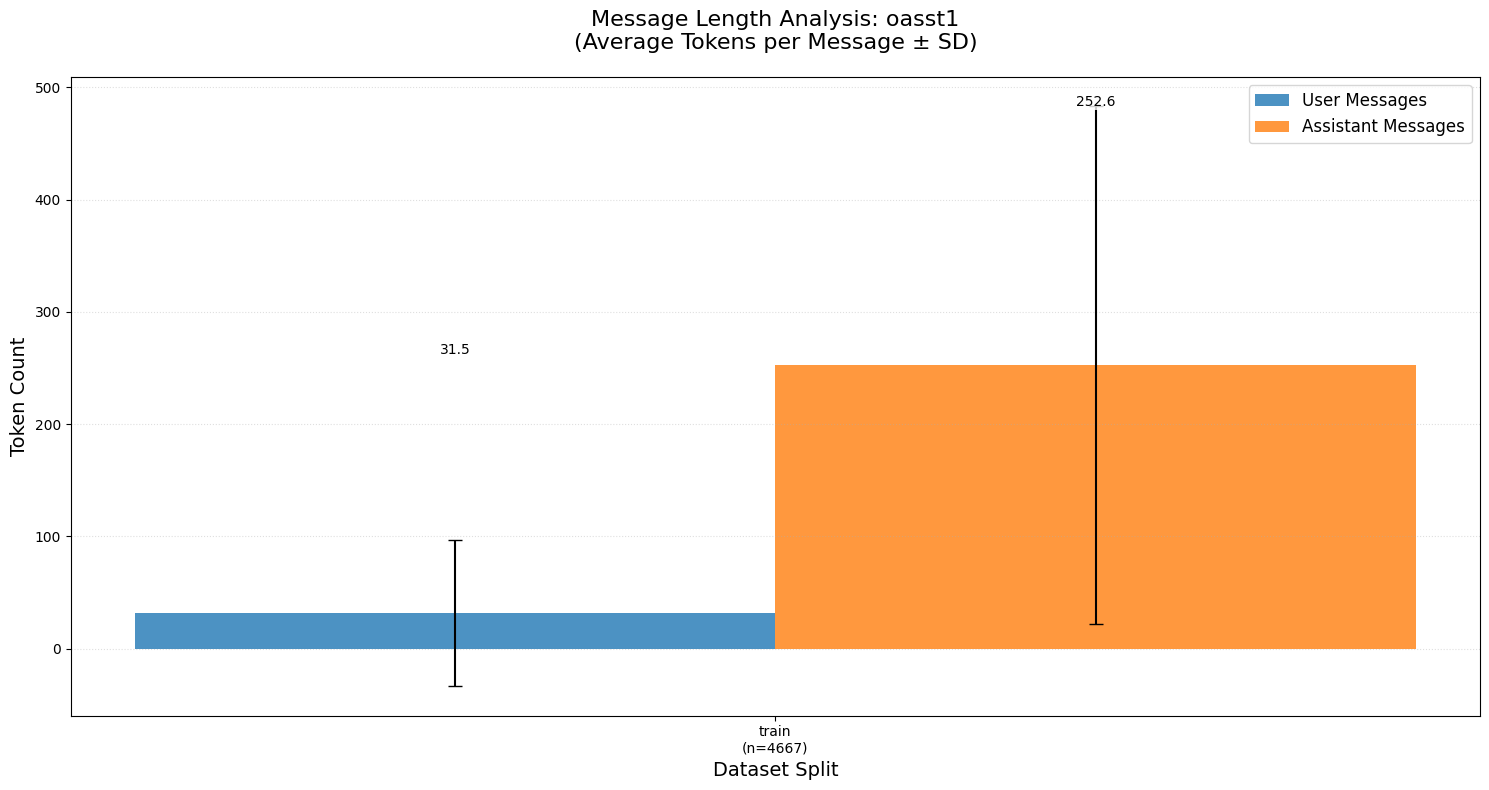

Processing openMathGsm8k: 100%|██████████| 1/1 [00:07<00:00,  7.37s/it]


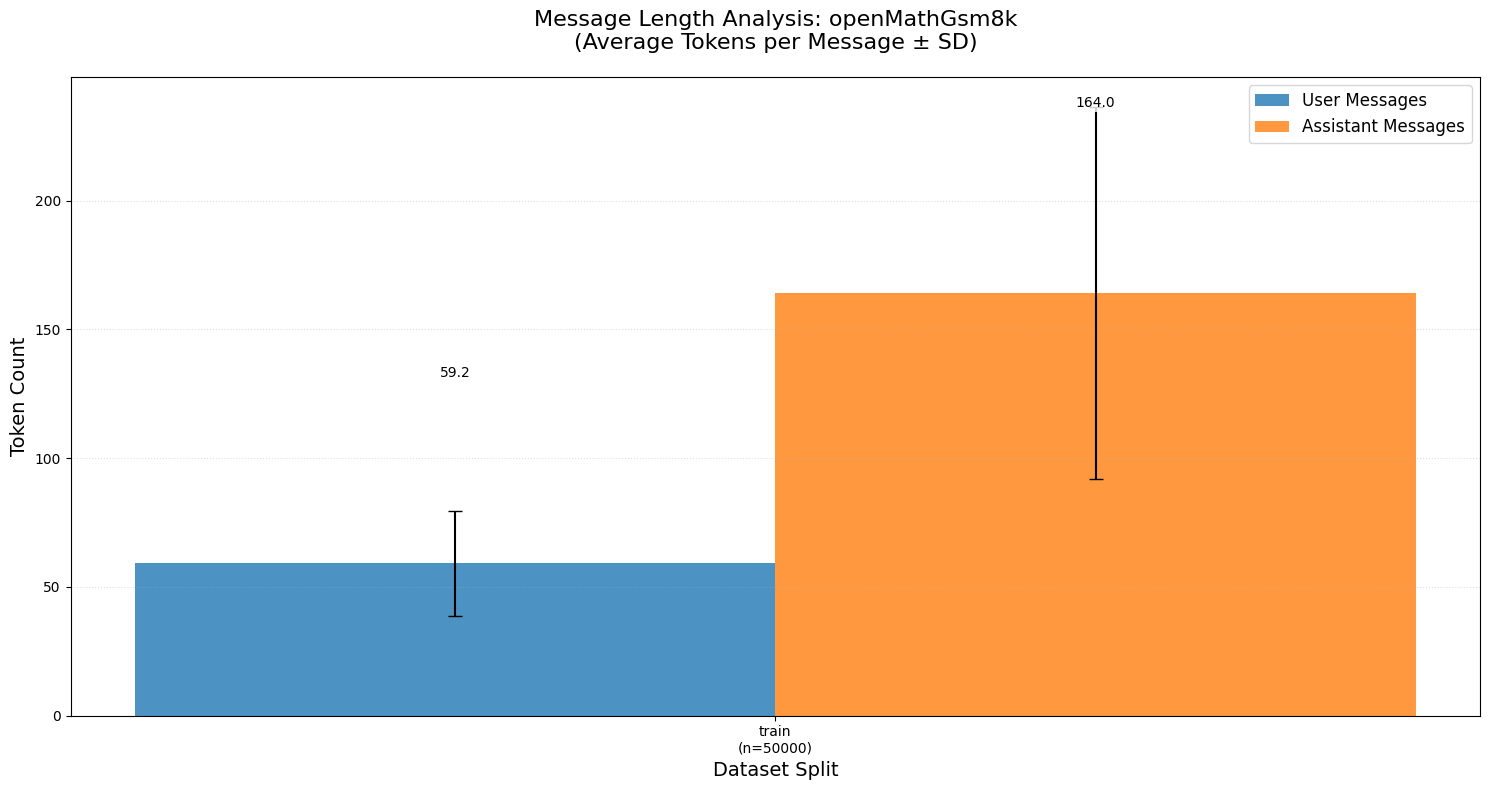

Processing sciriff: 100%|██████████| 1/1 [00:07<00:00,  7.80s/it]


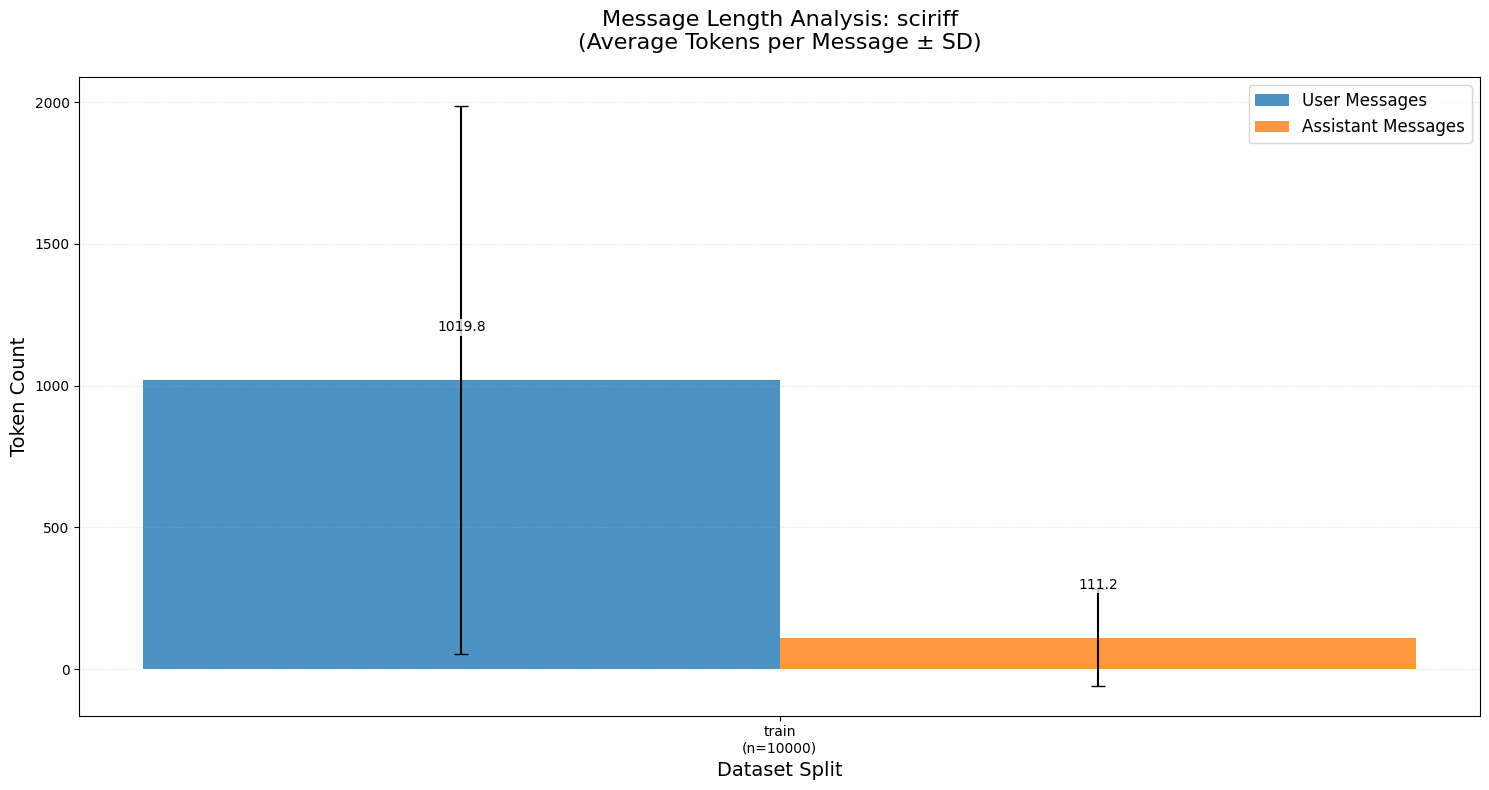

Processing tableGpt: 100%|██████████| 1/1 [00:01<00:00,  1.89s/it]


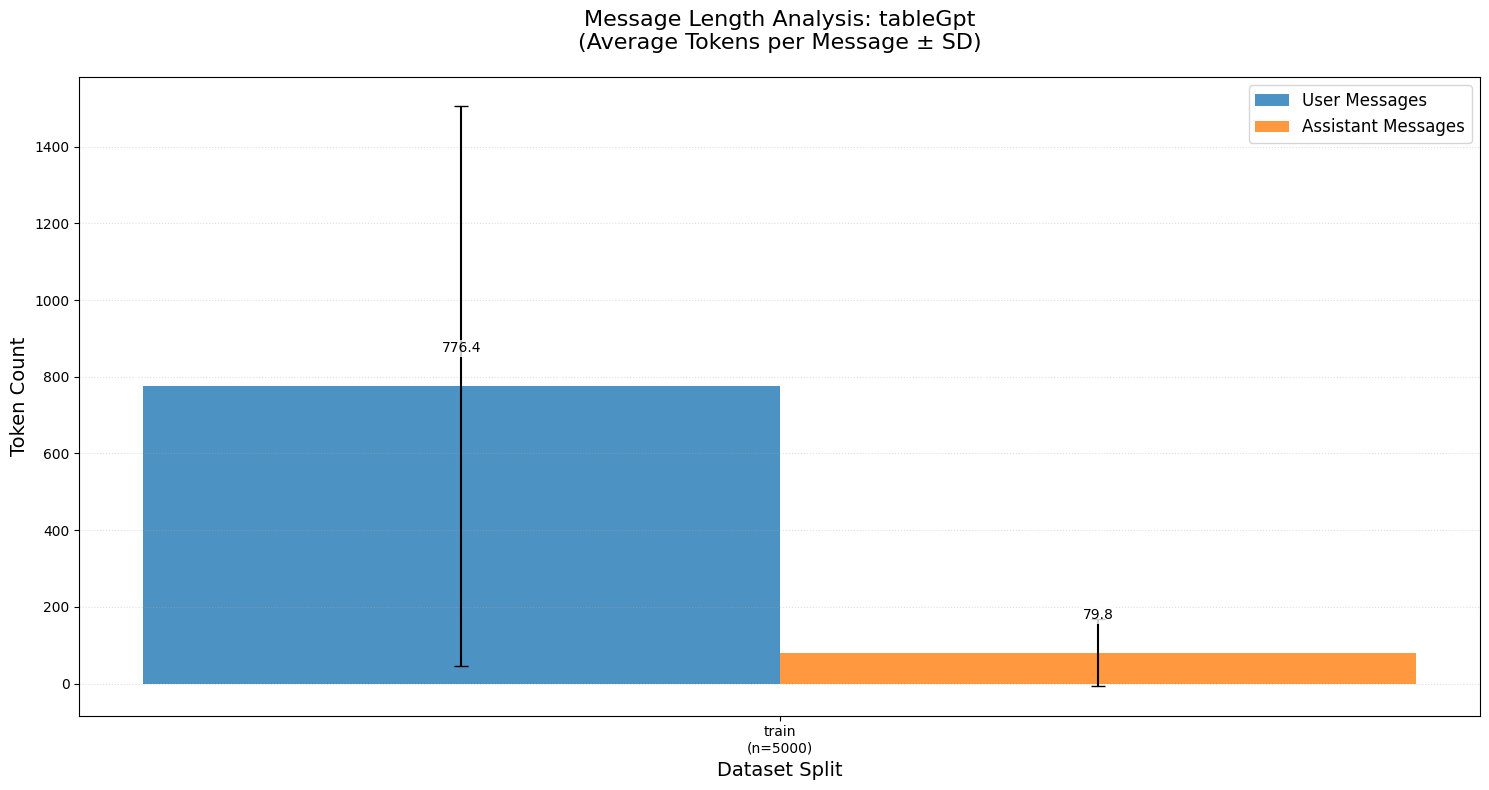

Processing tirMath: 100%|██████████| 1/1 [00:23<00:00, 23.75s/it]


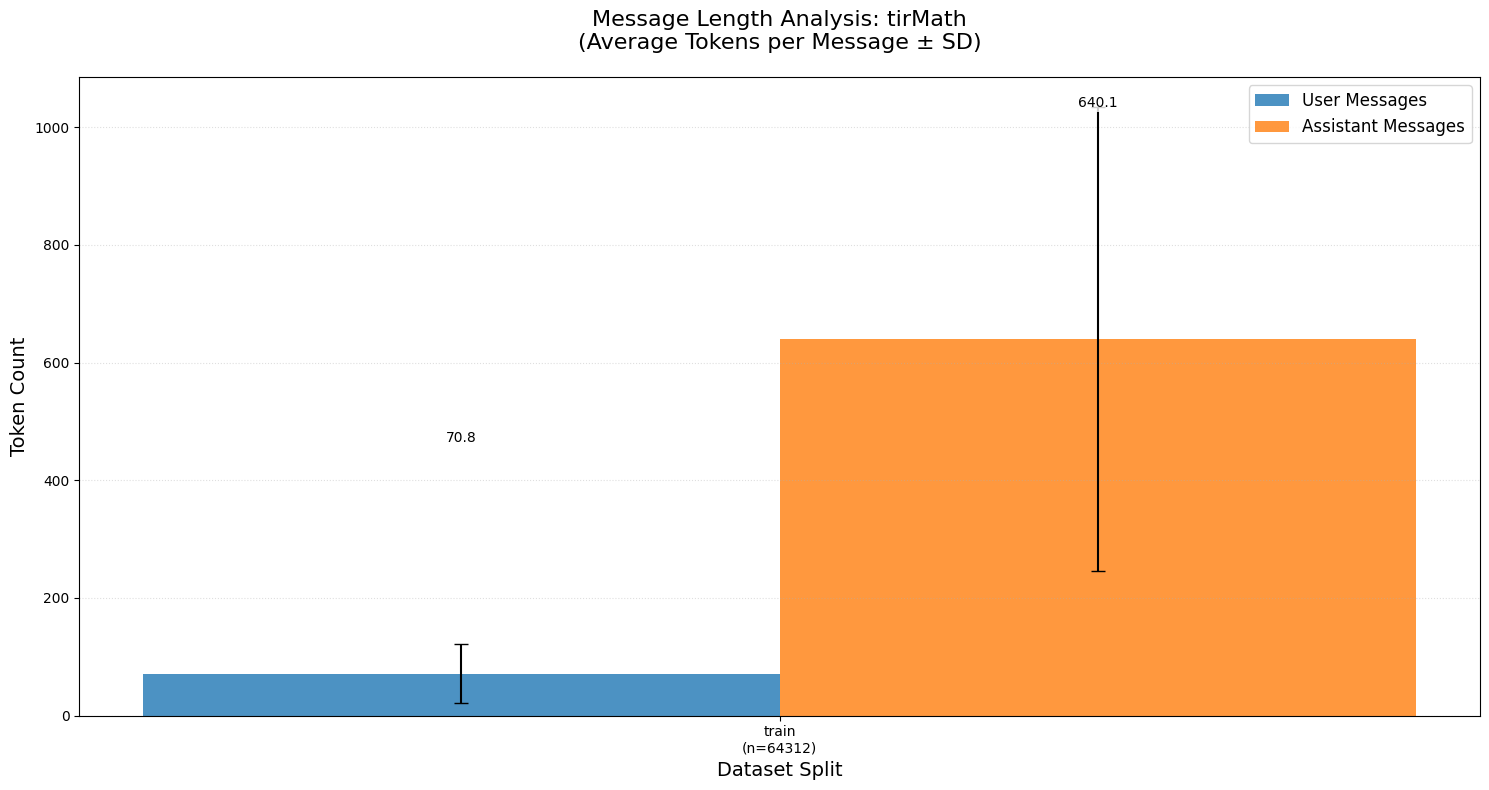

Processing wildChat: 100%|██████████| 1/1 [00:54<00:00, 54.58s/it]


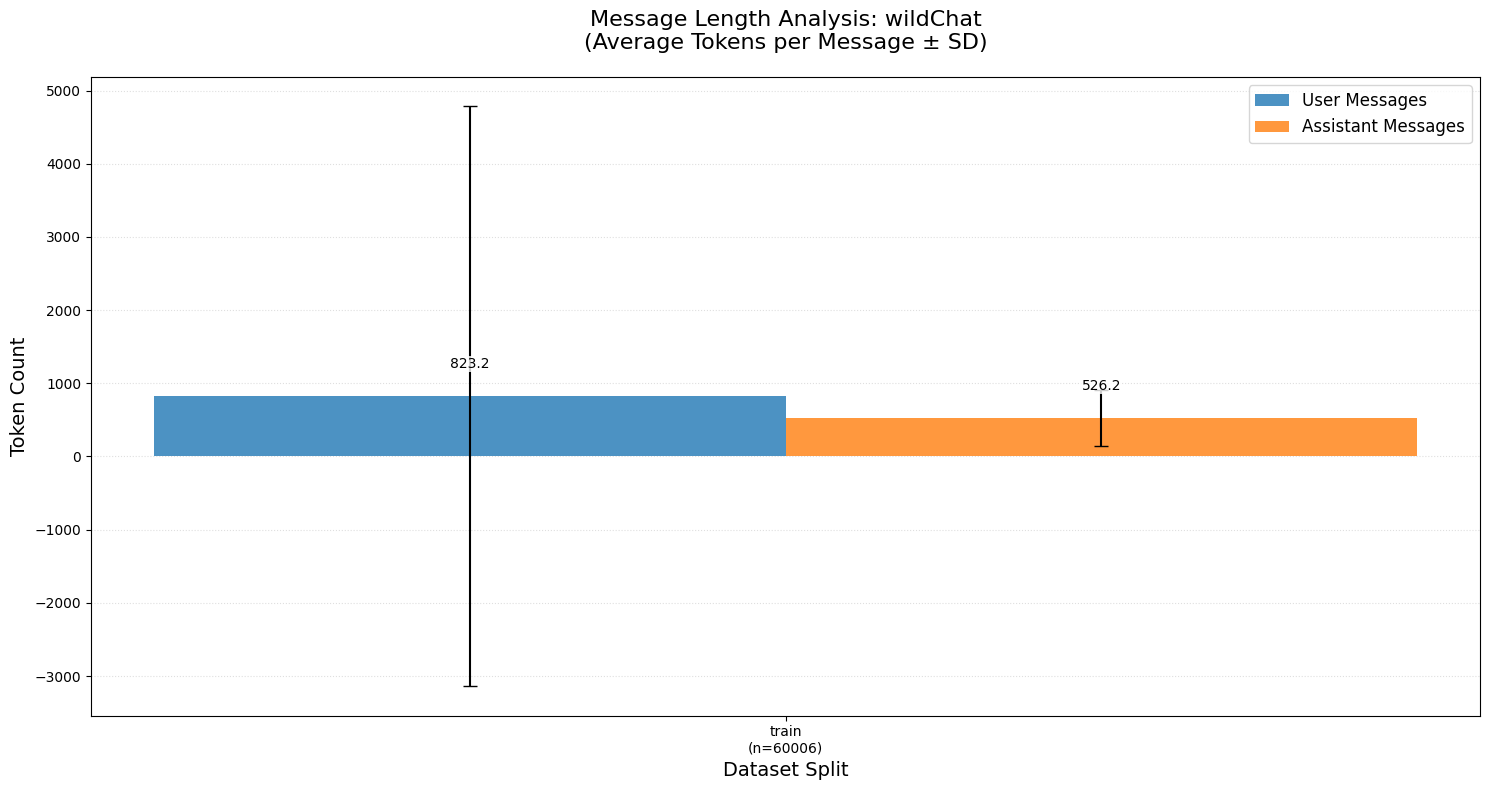

In [14]:
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

def batch_count_tokens(texts):
    """Count tokens for a batch of texts"""
    return [len(ids) for ids in tokenizer(texts, add_special_tokens=False)["input_ids"]]

def process_split(split_data):
    """Process a single split in parallel"""
    split, subset = split_data
    token_data = {"user": [], "assistant": []}
    sample_count = len(subset)
    
    # Batch process conversations
    batch_size = 1000
    for i in range(0, len(subset), batch_size):
        batch = subset[i:i+batch_size]
        
        # Pre-allocate role/content lists
        roles, contents = [], []
        for conv in batch["messages"]:
            for message in conv:
                roles.append(message["role"])
                contents.append(message["content"])
        
        # Batch tokenize
        if contents:
            token_counts = batch_count_tokens(contents)
            for role, count in zip(roles, token_counts):
                token_data[role].append(count)
    
    return split, sample_count, token_data

for name, subset in zip(instruction_finetuning_dataset_configs, instruction_finetuning_datasets):
    # --- Initialize figure ---
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Prepare data storage
    splits = [split for split in subset.keys() if split in subset]
    if not splits:
        print(f"Skipping {name} - no valid splits found")
        continue
        
    # Parallel processing
    with ThreadPoolExecutor() as executor:
        results = list(tqdm(
            executor.map(process_split, [(split, subset[split]) for split in splits]),
            total=len(splits),
            desc=f"Processing {name}"
        ))
    
    # Organize results
    token_data = {"user": {}, "assistant": {}}
    sample_counts = {}
    for split, count, data in results:
        sample_counts[split] = count
        token_data["user"][split] = data["user"]
        token_data["assistant"][split] = data["assistant"]
    
    # --- Plotting ---
    bar_width = 0.35
    index = np.arange(len(splits))
    
    # Plot user vs assistant side by side
    for i, role in enumerate(["user", "assistant"]):
        means = [np.mean(token_data[role][split]) if token_data[role][split] else 0 for split in splits]
        stds = [np.std(token_data[role][split]) if token_data[role][split] else 0 for split in splits]
        
        ax.bar(
            index + i * bar_width, 
            means, 
            bar_width,
            yerr=stds,
            label=f'{role.title()} Messages',
            color='#1f77b4' if role == 'user' else '#ff7f0e',
            alpha=0.8,
            capsize=5
        )
    
    # --- Customize plot ---
    ax.set_title(
        f'Message Length Analysis: {name}\n(Average Tokens per Message ± SD)', 
        fontsize=16,
        pad=20
    )
    ax.set_xlabel('Dataset Split', fontsize=14)
    ax.set_ylabel('Token Count', fontsize=14)
    ax.set_xticks(index + bar_width/2)
    ax.set_xticklabels([f"{split}\n(n={sample_counts[split]})" for split in splits])
    ax.legend(fontsize=12, loc='upper right')
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    
    # Add value labels
    for i, role in enumerate(["user", "assistant"]):
        for j, split in enumerate(splits):
            if token_data[role][split]:
                avg = np.mean(token_data[role][split])
                ax.text(
                    j + i * bar_width, 
                    avg + max(stds[j], 5),
                    f'{avg:.1f}',
                    ha='center',
                    fontsize=10,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1)
                )
    
    plt.tight_layout()
    plt.show()